#  NSR vs. PLATO passband

### Setup notebook

In [1]:
# Alow changes to the PlatoSim code outside this notebook
%load_ext autoreload
%autoreload 2

# Configure figure in notebook
%matplotlib notebook

### Imports

In [18]:
import os
import sys
import h5py
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import periodogram
from scipy.ndimage import median_filter
from zipfile import ZipFile

# PlatoSim
import platosim.plot            as pt
import platosim.utilities       as ut
import platosim.referenceFrames as rf
from platosim.lightcurve   import LightCurve
from platosim.matplotlibrc import setup_notebook
setup_notebook()

import warnings 
warnings.filterwarnings("ignore")

## Data Analysis: Indiviual N-CAM LCs

In [46]:
# User parameters
numStar = 2
idir  = "/lhome/nicholas/data/platosimPaper/NSR"
ofile = idir + "/results.ftr"
cfile = idir + "/starcat_all_SPF_CamVis24_NewCat_targets.ftr"

### Test example

In [69]:
# Load first star only
istar = f"{idir}/000000001"
phot = LightCurve(istar, mode="multi")
phot.unpack()

In [70]:
# Fetch all files
filenames = phot.files("hdf5")
filenames

['/lhome/nicholas/data/platosimPaper/NSR/000000001/000000001_Ncam1.1_Q1.hdf5',
 '/lhome/nicholas/data/platosimPaper/NSR/000000001/000000001_Ncam1.2_Q1.hdf5',
 '/lhome/nicholas/data/platosimPaper/NSR/000000001/000000001_Ncam1.3_Q1.hdf5',
 '/lhome/nicholas/data/platosimPaper/NSR/000000001/000000001_Ncam1.4_Q1.hdf5',
 '/lhome/nicholas/data/platosimPaper/NSR/000000001/000000001_Ncam1.5_Q1.hdf5',
 '/lhome/nicholas/data/platosimPaper/NSR/000000001/000000001_Ncam1.6_Q1.hdf5',
 '/lhome/nicholas/data/platosimPaper/NSR/000000001/000000001_Ncam2.1_Q1.hdf5',
 '/lhome/nicholas/data/platosimPaper/NSR/000000001/000000001_Ncam2.2_Q1.hdf5',
 '/lhome/nicholas/data/platosimPaper/NSR/000000001/000000001_Ncam2.3_Q1.hdf5',
 '/lhome/nicholas/data/platosimPaper/NSR/000000001/000000001_Ncam2.4_Q1.hdf5',
 '/lhome/nicholas/data/platosimPaper/NSR/000000001/000000001_Ncam2.5_Q1.hdf5',
 '/lhome/nicholas/data/platosimPaper/NSR/000000001/000000001_Ncam2.6_Q1.hdf5']

In [79]:
# Load the first light curve
nsr = []
for i in range(len(filenames)):
    lc = LightCurve(filenames[i], mode='single')
    nsr.append(lc.getNSR())

In [83]:
np.mean(nsr)/np.sqrt(len(nsr))

55.170940502909616

In [72]:
lc.getRMS()

101.54025810119091

In [108]:
lc.obs()

(2, 6, 1)

<IPython.core.display.Javascript object>


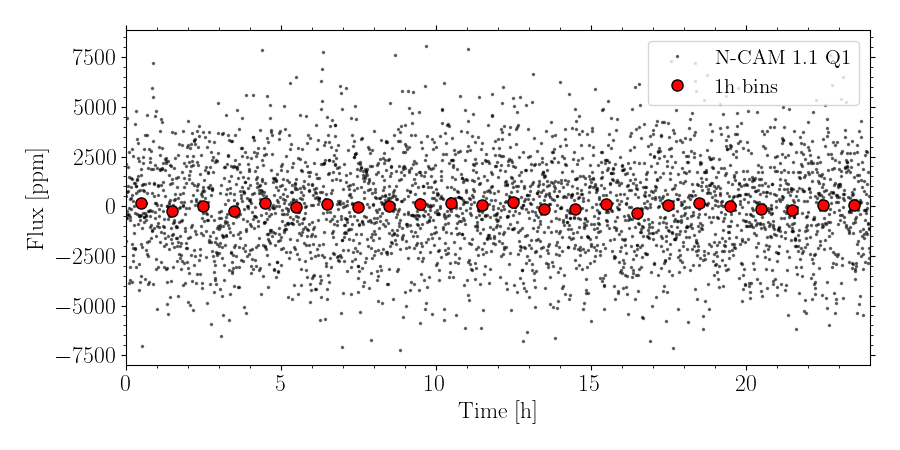

In [28]:
fig, ax = lc.plot(time_unit="h", flux_unit='ppm', binsize=1, alpha=0.5, figsize=(9,4.5));
# fig.savefig('camera_JitterNone_Star1.png', bbox_inches='tight', dpi=200)

## Multi mode for all stars

In [98]:
phot = LightCurve(idir, mode="multi")
phot.run_NSRvsMag_analysis(ofile, 10000, suffix="hdf5")

100%|██████████████████████████████████████████████████| 10000/10000 [10:29<00:00, 15.88it/s]                                                                                                               


In [106]:
# Load results and sort logically
df = pd.read_feather(ofile)

# Load input catalogue
dc = pd.read_feather(cfile)

# Merge the two data frames
df["mag"]  = dc.mag
df["ncon"] = dc.ncon
df.NSR *= np.sqrt(24)
# df["ncam"] = dc.ncams

df

,index,star,quarter,ncam,NSR,mag,ncon
0,0,1,1,12,61.719193,10.618521,1
1,1,2,1,18,48.007450,10.768657,0
2,2,3,1,12,75.593124,10.060707,0
3,3,4,1,12,46.293045,11.282410,0
4,4,5,1,6,120.647537,9.783687,0
...,...,...,...,...,...,...,...
9475,9475,9996,1,6,151.714325,10.776378,3
9476,9476,9997,1,6,56.322086,11.677792,1
9477,9477,9998,1,6,49.898476,11.218838,0
9478,9478,9999,1,6,94.441330,11.034813,0


<IPython.core.display.Javascript object>


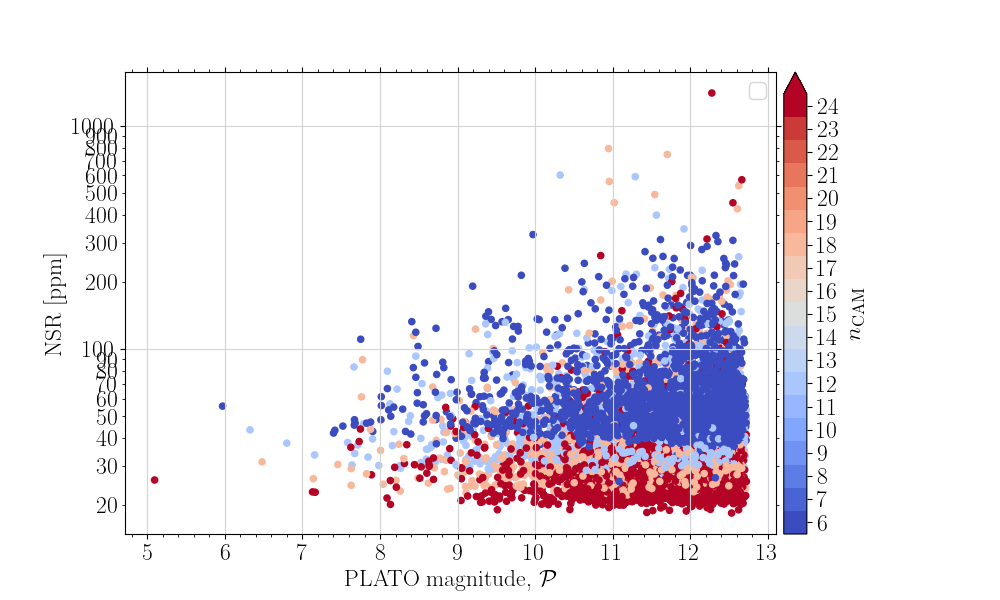

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


In [107]:
# Plot all data together
fig, ax = pt.plotNSRvsMagnitude(df, column="ncam", figsize=(10,6))

# Plot one of the outliers
# star = df1.loc[df1["star"] == 316]
# ax.scatter(star["mag"], star["NSR"], s=50, facecolors='none', edgecolors='r');
# fig.savefig('camera_JitterNone_NSR.png', bbox_inches='tight', dpi=200)

# fig.savefig('camera_JitterNone_con_dmag.png', bbox_inches='tight', dpi=200)

In [122]:
from platosim.plot import plotSubfieldAnimation

<IPython.core.display.Javascript object>


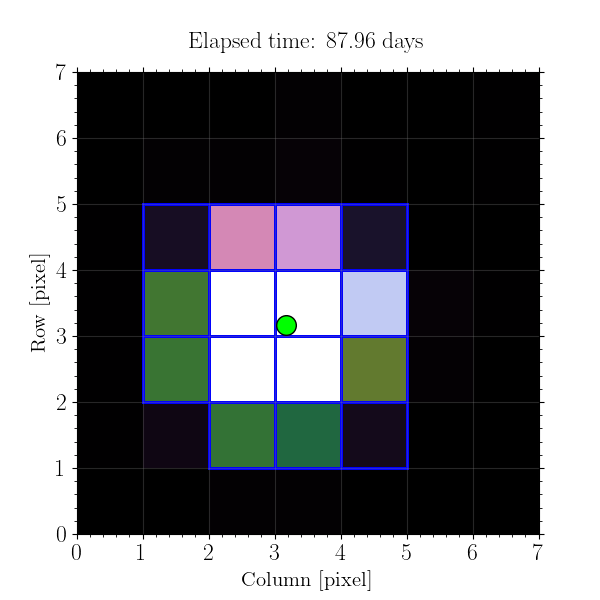

100%|██████████████████████████████████████████████████| 305/305 [00:06<00:00, 43.73it/s]                                                                                                                   


Creating GIF animation..


In [168]:
idir = "/lhome/nicholas/software/workdir/test/output"
filename = idir + "/000000000_Ncam1.1_Q1.hdf5"
plotSubfieldAnimation(filename, outputFileName=idir+"/animation", showStarPositions="PIC", skipNimages=1000, showMaskOfStarID=1)